# The baseline closed loop, step by step

One real shot through the simplest loop: syndrome data in -> controller (pulses to binary) -> syndrome packing -> Buffer 0 -> window manager -> weak decoder (its own memory; fetch, algorithm, release at a clock) -> Pauli frame. No reorder buffer, no strong tier, no confidence estimator.

Every number shown is measured inside the simulator on this run. The configured costs all come from one file, `experiments/baseline/baseline_closed_loop.yaml`.


In [1]:
import os
import sys

notebook_directory = os.getcwd()
repo_from_notebook_directory = os.path.join(notebook_directory, "..", "..")
running_inside_baseline_folder = notebook_directory.endswith("baseline")
if running_inside_baseline_folder:
    REPO = os.path.abspath(repo_from_notebook_directory)
else:
    REPO = notebook_directory
sys.path.insert(0, REPO)
os.chdir(REPO)

from decsim.config import microseconds


def row_as_strings(row: dict, columns: list) -> list:
    """One table row: the row's value under each column, as text."""
    values = []
    for column in columns:
        value = row.get(column, "")
        values.append(str(value))
    return values


def column_widths(columns: list, cells: list) -> list:
    """Width of each column: its header or its widest cell."""
    widths = []
    for index, column in enumerate(columns):
        width = len(column)
        for row in cells:
            width = max(width, len(row[index]))
        widths.append(width)
    return widths


def aligned_line(values: list, widths: list) -> str:
    """One printed line: each value padded to its column width."""
    padded = []
    for value, width in zip(values, widths):
        padded.append(value.ljust(width))
    return "  ".join(padded)


def table(rows: list, columns: list) -> None:
    """Print rows (dicts) as an aligned text table with the given columns."""
    cells = []
    for row in rows:
        cells.append(row_as_strings(row, columns))
    widths = column_widths(columns, cells)
    rules = []
    for width in widths:
        rules.append("-" * width)
    print(aligned_line(columns, widths))
    print(aligned_line(rules, widths))
    for row in cells:
        print(aligned_line(row, widths))


print("repo:", REPO)


repo: /scratch/gpfs/MARTONOSI/sk2415/qlx-qec-sandbox/decsim


## 1. The configuration: every cost in one place

Round period, decoder card, engine cycles and clock, controller times, the link cards, the Pauli frame commit. Nothing else in the loop carries a number.


In [2]:
CONFIG_PATH = "experiments/baseline/baseline_closed_loop.yaml"
print(open(CONFIG_PATH).read())


# Baseline closed loop: the single source of every parameter of the experiment.
# Every number that costs simulated time carries its source next to it.

code_task: surface_code:rotated_memory_z     # stim generator task (real detector data)
distance: 3
rounds_per_shot: 60                          # QEC rounds per shot
windowing:
  scheme: sliding                            # sliding | parallel | sandwich | naive_online (no windowing: one decode per operation after all rounds)
  commit_rounds: null                        # rounds committed per window; null = d
  buffer_rounds: null                        # look-ahead rounds per window; null = d

# The sweep: every point is the cross product of the three axes, `shots` runs each (seeds 0..shots-1).
# Every shot reports timing and whether the logical prediction was wrong, so:
#   timing only:   one physical_error_probability, few shots (10)
#   LER only:      one round_period_us, one algorithm_latency_us, many shots (200+), several probabi

## 2. Tracing hooks

Each stage of the loop is a real method. We wrap those methods so every call leaves one record in `TRACE` (simulated time, stage name, the data that passed). The loop itself is untouched.


In [3]:
from decsim.qpu.cycle_clock import QPUDevice
from decsim.controller.controller import Controller
from decsim.controller.syndrome_ingress import SyndromeIngress
from decsim.syndrome_buffer.syndrome_buffer import SyndromeBuffer
from decsim.windows.window_manager import WindowManager
from decsim.windows.window_boundaries import BoundaryCourier
from decsim.decoders.decoder_manager import DecoderManager
from decsim.decoders.decoder_memory import DecoderMemory
from decsim.pauli_frame.pauli_frame import PauliFrame

TRACE = []
CLOCK = {"engine": None}


def record(stage: str, **data) -> None:
    """Append one trace record stamped with the simulated time."""
    now_us = microseconds(CLOCK["engine"].now)
    TRACE.append(dict(t=now_us, stage=stage, **data))


def wrap(cls, method_name: str, before=None, after=None) -> None:
    """Replace cls.method_name with a version that calls before(...) first and after(...) last."""
    original = getattr(cls, method_name)

    def wrapped(self, *args, **kwargs):
        if before is not None:
            before(self, *args, **kwargs)
        result = original(self, *args, **kwargs)
        if after is not None:
            after(self, result, *args, **kwargs)
        return result

    setattr(cls, method_name, wrapped)


def bits_as_text(bits) -> str:
    text = ""
    for bit in bits:
        text += str(int(bit))
    return text


# ---- stage hooks, in path order

def on_qpu_issue(qpu, command):
    CLOCK["engine"] = qpu.engine
    record("controller -> qpu: issue", op=command.operation.name, rounds=command.round_count,
           cycle_us=microseconds(command.round_ticks), starts_at=microseconds(qpu.next_boundary()))


def on_qpu_round(qpu, payloads, operation):
    for payload in payloads:
        record("qpu: round emitted", op=operation.name, round=payload.round_index,
               bits=bits_as_text(payload.bits), size_bits=payload.size_bits)


def on_controller_readout(controller, readout, route):
    binary_us = microseconds(controller.binary_availability_ticks)
    record("controller: readout accepted (pulses -> binary)", round=readout.round_index, binary_us=binary_us)


def on_packing(ingress, payload, route, **kwargs):
    fragment = f"{payload.fragment_index + 1}/{payload.n_fragments}"
    record("packing: fragment relayed", round=payload.round_index, fragment=fragment, size_bits=payload.size_bits)


def on_buffer_retained(buffer, packet, round_identity, **kwargs):
    snapshot = buffer.snapshot()
    retained_rounds = []
    for identity in snapshot.retained_identities:
        retained_rounds.append(identity[1])
    first_fragment = packet.fragments[0]
    record("buffer 0: round retained", round=round_identity[1], bits=bits_as_text(first_fragment.bits),
           occupancy=snapshot.occupancy, retained=retained_rounds)


def window_state_text(window_manager) -> str:
    parts = []
    for (op_id, window_index), window in sorted(window_manager.windows.items()):
        state = "READY" if window.t_data_complete else "waiting"
        parts.append(f"W{window_index}[{window.commit_lo}-{window.commit_hi}|buf->{window.buffer_hi}] {state}")
    return "  ".join(parts)


def on_window_round(window_manager, result, packet):
    record("window manager: round arrived", round=packet.round_index, windows=window_state_text(window_manager))


def free_units_of(decoder_manager) -> dict:
    free = {}
    for pool, units in decoder_manager._free_units.items():
        free[pool] = list(units)
    return free


def on_enqueue(decoder_manager, job, reserve_transfer=None):
    record("decoder manager: window enqueued", window=job.label, free_units=free_units_of(decoder_manager))


def on_unit_assigned(decoder_manager, result, pool, job):
    record("decoder manager: unit assigned", window=job.label, unit=job.unit, free_units=free_units_of(decoder_manager))


def on_memory_deposit(memory, decoder_input, job):
    rounds = []
    for round_packet in decoder_input.rounds:
        rounds.append(round_packet.round_index)
    record("decoder memory: input landed in unit", unit=memory.unit, window=job.label, rounds=rounds,
           occupied_rounds=memory.occupied_rounds)


def on_decode_start(decoder_manager, job):
    record("decoder manager: start decode", window=job.label, unit=job.unit)


def on_decode_result(decoder_manager, job, result):
    rounds_fetched = []
    defects = 0
    for fragment in job.payloads:
        rounds_fetched.append(fragment.round_index)
        defects += int(sum(fragment.bits))
    correction_weight = None
    if result.correction is not None:
        correction_weight = int(sum(result.correction))
    record("decoder engine: result", window=job.label, syndrome_rounds_fetched=rounds_fetched, defects=defects,
           correction_weight=correction_weight, logical=result.logical_observables, boundary_defects=result.boundary_defects)


def on_boundary_sent(courier, window, operation, boundary, **kwargs):
    dependents = []
    for (_, window_index) in window.dependents:
        dependents.append(f"W{window_index}")
    record("boundary handoff (DD) at decode done", window=f"W{window.k}", to=dependents, boundary=boundary)


def on_frame_commit(frame, **kwargs):
    window_index = kwargs["window_key"][1]
    record("pauli frame: correction arrived (after WDO)", window=f"W{window_index}", logical=kwargs["logical_observables"])


wrap(QPUDevice, "issue", before=on_qpu_issue)
wrap(QPUDevice, "_emit", before=on_qpu_round)
wrap(Controller, "accept_qpu_readout", before=on_controller_readout)
wrap(SyndromeIngress, "relay_qpu_readout", before=on_packing)
wrap(SyndromeBuffer, "finish_packing", after=on_buffer_retained)
wrap(WindowManager, "on_syndrome_arrival", after=on_window_round)
wrap(DecoderManager, "enqueue", before=on_enqueue)
wrap(DecoderManager, "_start_job", after=on_unit_assigned)
wrap(DecoderMemory, "deposit", after=on_memory_deposit)
wrap(DecoderManager, "_begin_service", before=on_decode_start)
wrap(DecoderManager, "_on_decode_done", before=on_decode_result)
wrap(BoundaryCourier, "send", before=on_boundary_sent)
wrap(PauliFrame, "commit_weak_correction", before=on_frame_commit)
print("hooks installed:", 13)


hooks installed: 13


## 3. One traced shot

The run is built from the yaml with three changes so the walkthrough fits on screen: 9 rounds instead of 60, physical error probability 0.02 instead of 0.001 (so defects and corrections are visible), and the weak decoder as real PyMatching whose algorithm stage lasts the wall clock of the call. Round period 1.0 us, seed 0.


In [4]:
from experiments.baseline.baseline_closed_loop import build_run, load_config

config = load_config(CONFIG_PATH)
config["rounds_per_shot"] = 9

spec, decoder_engine = build_run(config, physical_error_probability=0.02, round_period_us=1.0,
                                 algorithm_latency_us="measured", seed=0)
done = spec.build()

print("terminal status:", done.result.terminal_status)
print("events traced:", len(TRACE))


terminal status: complete
events traced: 60


## 4. Planner and controller -> QPU

Before any data exists the planner resolves the operation (round count, cycle, code geometry) and lays out the sliding windows; the window manager holds them empty. Then the controller commands the QPU, which starts on its next cycle boundary. The operation reaches the QPU through the controller.


In [5]:
operation = spec.ops[0]
resolved = done.controller._resolved_operations[operation.id]
print("operation:", operation.name, "| qubits", operation.qubits, "| patches", operation.patches)
print("rounds:", resolved.round_count, "| cycle:", microseconds(resolved.round_ticks), "us")
print("code geometry:", resolved.code_geometry)
print()

window_rows = []
for (op_id, window_index), window in sorted(done.window_manager.windows.items()):
    waits_on = []
    for (_, other_index) in window.deps:
        waits_on.append(f"W{other_index}")
    window_rows.append({"window": f"W{window_index}", "commit": f"{window.commit_lo}-{window.commit_hi}",
                        "buffer through": window.buffer_hi, "rounds read": window.n_rounds, "waits on": waits_on})
table(window_rows, ["window", "commit", "buffer through", "rounds read", "waits on"])
print()

issue_rows = []
for event in TRACE:
    if event["stage"] == "controller -> qpu: issue":
        issue_rows.append(event)
table(issue_rows, ["t", "op", "rounds", "cycle_us", "starts_at"])


operation: memory | qubits (0,) | patches (0,)
rounds: 9 | cycle: 1.0 us
code geometry: ResolvedCodeGeometry(code_name='rotated surface code (d=3)', distance=3, commit_round_count=3, buffer_round_count=3, minimum_leading_buffer_round_count=3, minimum_trailing_buffer_round_count=3, one_patch_spatial_node_count=9, buffer_floor_override_active=False)

window  commit  buffer through  rounds read  waits on
------  ------  --------------  -----------  --------
W0      1-3     6               6            []      
W1      4-9     9               6            ['W0']  

t    op      rounds  cycle_us  starts_at
---  ------  ------  --------  ---------
0.0  memory  9       1.0       0.0      


## 5. What is fed in: one syndrome round per cycle

Each round is the detector bits of that QEC cycle, sampled from the Stim circuit (real data; the seed picks the noise realization). The QPU emits one round per cycle and hands it to the controller.


In [6]:
round_rows = []
for event in TRACE:
    if event["stage"] == "qpu: round emitted":
        round_rows.append(event)
table(round_rows, ["t", "op", "round", "bits", "size_bits"])


t    op      round  bits          size_bits
---  ------  -----  ------------  ---------
1.0  memory  1      0000          4        
2.0  memory  2      10110000      8        
3.0  memory  3      10100000      8        
4.0  memory  4      00000000      8        
5.0  memory  5      00000000      8        
6.0  memory  6      10000000      8        
7.0  memory  7      10000000      8        
8.0  memory  8      01001000      8        
9.0  memory  9      100100000001  12       


## 6. Controller (pulses to binary), syndrome packing, link C2B, Buffer 0

The controller accepts the readout after the QC link and its binary-availability time (0 in this card). Packing assembles a round's fragments (one fragment per round here, so t_pack is a no-op). The packed round crosses C2B (priced: 0.10 us + bits / 1000 bits per us) into Buffer 0, which retains it until its windows are done. The last table shows what Buffer 0 holds after each round.


In [7]:
controller_rows = []
for event in TRACE:
    if event["stage"] in ("controller: readout accepted (pulses -> binary)", "packing: fragment relayed"):
        controller_rows.append(event)
table(controller_rows, ["t", "stage", "round", "binary_us", "fragment", "size_bits"])
print()

transfers = done.result.link_traffic["transfers"]
c2b_rows = []
for transfer in transfers:
    if transfer["path"] != "c2b":
        continue
    c2b_rows.append({"round": transfer["attribution"]["round_lo"],
                     "sent": microseconds(transfer["send_ticks"]),
                     "delivered": microseconds(transfer["delivery_ticks"]),
                     "bits": transfer["payload_bits"],
                     "delay_us": microseconds(transfer["total_delay_ticks"])})
table(c2b_rows, ["round", "sent", "delivered", "bits", "delay_us"])
print()

buffer_rows = []
for event in TRACE:
    if event["stage"] == "buffer 0: round retained":
        buffer_rows.append(event)
table(buffer_rows, ["t", "round", "bits", "occupancy", "retained"])


t    stage                                            round  binary_us  fragment  size_bits
---  -----------------------------------------------  -----  ---------  --------  ---------
1.0  controller: readout accepted (pulses -> binary)  1      0.0                           
1.0  packing: fragment relayed                        1                 1/1       4        
2.0  controller: readout accepted (pulses -> binary)  2      0.0                           
2.0  packing: fragment relayed                        2                 1/1       8        
3.0  controller: readout accepted (pulses -> binary)  3      0.0                           
3.0  packing: fragment relayed                        3                 1/1       8        
4.0  controller: readout accepted (pulses -> binary)  4      0.0                           
4.0  packing: fragment relayed                        4                 1/1       8        
5.0  controller: readout accepted (pulses -> binary)  5      0.0                

## 7. Window manager: when enough rounds are there

A window is ready when its commit rounds and its buffer rounds have all arrived. Sliding windows are serial: W1 also waits for W0's boundary.


In [8]:
window_manager_rows = []
for event in TRACE:
    if event["stage"] == "window manager: round arrived":
        window_manager_rows.append(event)
table(window_manager_rows, ["t", "round", "windows"])


t      round  windows                                       
-----  -----  ----------------------------------------------
1.254  1      W0[1-3|buf->6] waiting  W1[4-9|buf->9] waiting
2.258  2      W0[1-3|buf->6] waiting  W1[4-9|buf->9] waiting
3.258  3      W0[1-3|buf->6] waiting  W1[4-9|buf->9] waiting
4.258  4      W0[1-3|buf->6] waiting  W1[4-9|buf->9] waiting
5.258  5      W0[1-3|buf->6] waiting  W1[4-9|buf->9] waiting
6.258  6      W0[1-3|buf->6] READY  W1[4-9|buf->9] waiting  
7.258  7      W0[1-3|buf->6] READY  W1[4-9|buf->9] waiting  
8.258  8      W0[1-3|buf->6] READY  W1[4-9|buf->9] waiting  
9.262  9      W0[1-3|buf->6] READY  W1[4-9|buf->9] READY    


## 8. Decoder manager: the weak scheduler assigns a unit

The ready window is queued; the manager finds a free weak unit and only then asks for the transfer ("I found an ASIC, send the window").


In [9]:
decoder_manager_rows = []
for event in TRACE:
    if event["stage"] in ("decoder manager: window enqueued", "decoder manager: unit assigned"):
        decoder_manager_rows.append(event)
table(decoder_manager_rows, ["t", "stage", "window", "unit", "free_units"])


t       stage                             window                  unit  free_units      
------  --------------------------------  ----------------------  ----  ----------------
6.258   decoder manager: window enqueued  memory W0 [commit 1-3]        {'default': [0]}
6.258   decoder manager: unit assigned    memory W0 [commit 1-3]  0     {'default': []} 
20.016  decoder manager: window enqueued  memory W1 [commit 4-9]        {'default': [0]}
20.016  decoder manager: unit assigned    memory W1 [commit 4-9]  0     {'default': []} 


## 9. The decoder has its own memory: transfer over CWD, then the input sits in the unit

The window travels over CWD (2.0 us here) into the assigned unit's decoder memory. Decoding cannot start before the data has landed there. This is the ASIC's memory component; its compute component is the engine in the next section.


In [10]:
cwd_rows = []
for transfer in transfers:
    if transfer["path"] != "cwd":
        continue
    attribution = transfer["attribution"]
    cwd_rows.append({"window": f"W{attribution['window_id']}",
                     "rounds": f"{attribution['round_lo']}-{attribution['round_hi']}",
                     "sent": microseconds(transfer["send_ticks"]),
                     "delivered": microseconds(transfer["delivery_ticks"]),
                     "bits": transfer["payload_bits"],
                     "delay_us": microseconds(transfer["total_delay_ticks"])})
table(cwd_rows, ["window", "rounds", "sent", "delivered", "bits", "delay_us"])
print()

memory_rows = []
for event in TRACE:
    if event["stage"] == "decoder memory: input landed in unit":
        memory_rows.append(event)
table(memory_rows, ["t", "unit", "window", "rounds", "occupied_rounds"])


window  rounds  sent    delivered  bits  delay_us
------  ------  ------  ---------  ----  --------
W0      1-6     6.258   8.258      44    2.0     
W1      4-9     20.016  22.016     52    2.0     

t       unit  window                  rounds              occupied_rounds
------  ----  ----------------------  ------------------  ---------------
8.258   0     memory W0 [commit 1-3]  [1, 2, 3, 4, 5, 6]  6              
22.016  0     memory W1 [commit 4-9]  [4, 5, 6, 7, 8, 9]  6              


## 10. The decoder engine: fetch cycles, the algorithm, release cycles, at a clock

Inside the weak decoder: fetch reads the window out of the unit's memory (`fetch_cycles_per_round` cycles per round), the algorithm runs (here the real PyMatching call, its wall clock charged as simulated time; the ASIC card charges 0.028 us instead), release writes the correction out (`release_cycles_per_job` cycles). Cycles become time through `frequency_mhz` (250 MHz: one cycle is 0.004 us). The output latency is reported as time.


In [11]:
start_rows = []
for event in TRACE:
    if event["stage"] == "decoder manager: start decode":
        start_rows.append(event)
table(start_rows, ["t", "window", "unit"])
print()

stage_rows = []
for stage_record in decoder_engine.stage_records:
    duration_us = microseconds(stage_record.end_ticks - stage_record.start_ticks)
    stage_rows.append({"window": f"W{stage_record.window_id}", "stage": stage_record.stage,
                       "cycles": stage_record.cycles, "start": microseconds(stage_record.start_ticks),
                       "end": microseconds(stage_record.end_ticks), "duration_us": duration_us,
                       "measured_ns": stage_record.measured_ns})
table(stage_rows, ["window", "stage", "cycles", "start", "end", "duration_us", "measured_ns"])
print()

result_rows = []
for event in TRACE:
    if event["stage"] == "decoder engine: result":
        result_rows.append(event)
table(result_rows, ["t", "window", "syndrome_rounds_fetched", "defects", "correction_weight", "logical", "boundary_defects"])


t       window                  unit
------  ----------------------  ----
8.258   memory W0 [commit 1-3]  0   
22.016  memory W1 [commit 4-9]  0   

window  stage      cycles  start   end     duration_us  measured_ns
------  ---------  ------  ------  ------  -----------  -----------
W0      fetch      6       8.258   8.282   0.024        None       
W0      algorithm  None    8.282   19.512  11.23        11230      
W0      release    1       19.512  19.516  0.004        None       
W1      fetch      6       22.016  22.04   0.024        None       
W1      algorithm  None    22.04   29.71   7.67         7670       
W1      release    1       29.71   29.714  0.004        None       

t       window                  syndrome_rounds_fetched  defects  correction_weight  logical  boundary_defects
------  ----------------------  -----------------------  -------  -----------------  -------  ----------------
19.516  memory W0 [commit 1-3]  [1, 2, 3, 4, 5, 6]       6        3                 

## 11. Boundary to the next window (DD) and the correction to the Pauli frame (WDO)

At decode done the boundary goes to the dependent window over DD (0.5 us) and the correction goes to the Pauli frame over WDO (1.0 us); the frame commits it after `commit_us`. There is nothing between the decoder and the frame.


In [12]:
boundary_rows = []
for event in TRACE:
    if event["stage"] == "boundary handoff (DD) at decode done":
        boundary_rows.append(event)
table(boundary_rows, ["t", "window", "to", "boundary"])
print()

output_link_rows = []
for transfer in transfers:
    if transfer["path"] not in ("dd", "wdo"):
        continue
    output_link_rows.append({"path": transfer["path"],
                             "window": f"W{transfer['attribution']['window_id']}",
                             "sent": microseconds(transfer["send_ticks"]),
                             "delivered": microseconds(transfer["delivery_ticks"]),
                             "delay_us": microseconds(transfer["total_delay_ticks"])})
table(output_link_rows, ["path", "window", "sent", "delivered", "delay_us"])
print()

frame_rows = []
for frame_record in done.pauli_frame.snapshot().records:
    frame_rows.append({"window": f"W{frame_record.window_key[1]}",
                       "accepted": microseconds(frame_record.accepted_ticks),
                       "committed": microseconds(frame_record.committed_ticks),
                       "logical": frame_record.logical_observables})
table(frame_rows, ["window", "accepted", "committed", "logical"])


t       window  to      boundary                                                                                                                                            
------  ------  ------  ----------------------------------------------------------------------------------------------------------------------------------------------------
19.516  W0      ['W1']  DependencyResidual(detector_ids=(4, 6, 7, 12, 14), defects={2: [1, 0, 1, 1], 3: [1, 0, 1]})                                                         
29.714  W1      []      DependencyResidual(detector_ids=(36, 44, 53, 56, 60, 63, 71), defects={6: [1], 7: [1], 8: [0, 1, 0, 0, 1], 9: [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]})

path  window  sent    delivered  delay_us
----  ------  ------  ---------  --------
dd    W0      19.516  20.016     0.5     
wdo   W0      19.516  20.516     1.0     
wdo   W1      29.714  30.714     1.0     

window  accepted  committed  logical
------  --------  ---------  -------
W0      20.516    20.5

## 12. What comes out: the frame's prediction against the truth, and the whole timeline


In [13]:
operation_result = done.result.operation_results[0]
print("predicted logical observables:", operation_result.logical_observables)
print("truth:", operation_result.observable_truth)
print("logical failure:", operation_result.logical_failure)
print()

timeline_rows = []
for (op_id, window_index), window in sorted(done.window_manager.windows.items()):
    timeline_rows.append({"window": f"W{window_index}",
                          "first_round": microseconds(window.t_first_round),
                          "data_complete": microseconds(window.t_data_complete),
                          "queued": microseconds(window.t_queued),
                          "unit_assigned": microseconds(window.t_dispatch),
                          "decode_done": microseconds(window.t_done)})
table(timeline_rows, ["window", "first_round", "data_complete", "queued", "unit_assigned", "decode_done"])
print()

for line in done.engine.log_lines:
    print(line)


predicted logical observables: (1,)
truth: (1,)
logical failure: False

window  first_round  data_complete  queued  unit_assigned  decode_done
------  -----------  -------------  ------  -------------  -----------
W0      1.254        6.258          6.258   6.258          19.516     
W1      4.258        9.262          20.016  20.016         29.714     

[  0.000 us] Controller: START memory  (Clifford, qubits (0,))
[  1.000 us] QPU: memory fires round 1/9
[  1.254 us] DecoderCluster: round 1 of memory arrived (op now has rounds 1..1)
[  2.000 us] QPU: memory fires round 2/9
[  2.258 us] DecoderCluster: round 2 of memory arrived (op now has rounds 1..2)
[  3.000 us] QPU: memory fires round 3/9
[  3.258 us] DecoderCluster: round 3 of memory arrived (op now has rounds 1..3)
[  4.000 us] QPU: memory fires round 4/9
[  4.258 us] DecoderCluster: round 4 of memory arrived (op now has rounds 1..4)
[  5.000 us] QPU: memory fires round 5/9
[  5.258 us] DecoderCluster: round 5 of memory arrived 

## 13. Latency at every point of the path, for this shot

The fourteen points the sweep reports, measured on this run: per window, mean and max in microseconds. Simulated times, not paper numbers. The last table is one window's critical path: each step's start, end and duration, in order.


In [14]:
import statistics

from experiments.baseline.baseline_closed_loop import POINTS, collect_samples

samples = collect_samples(done, decoder_engine)
point_rows = []
for point in POINTS:
    values = samples[point]
    if values:
        mean_us = round(statistics.fmean(values), 3)
        max_us = round(max(values), 3)
    else:
        mean_us = 0.0
        max_us = 0.0
    point_rows.append({"point": point, "windows": len(values), "mean_us": mean_us, "max_us": max_us})
table(point_rows, ["point", "windows", "mean_us", "max_us"])
print()

last_window_key = sorted(done.window_manager.windows)[-1]
last_window = done.window_manager.windows[last_window_key]
last_window_index = last_window_key[1]
frame_record_of_last_window = None
for frame_record in done.pauli_frame.snapshot().records:
    if frame_record.window_key[1] == last_window_index:
        frame_record_of_last_window = frame_record
stage_records_of_last_window = decoder_engine.stage_records_for(last_window_key[0], last_window_index)
cwd_delivered = None
for transfer in transfers:
    if transfer["path"] == "cwd" and transfer["attribution"]["window_id"] == last_window_index:
        cwd_delivered = transfer["delivery_ticks"]

critical_path = []
critical_path.append(("first round arrives", last_window.t_first_round, last_window.t_first_round))
critical_path.append(("buffer fill (waiting on the QPU)", last_window.t_first_round, last_window.t_data_complete))
critical_path.append(("dependency block (previous window)", last_window.t_data_complete, last_window.t_queued))
critical_path.append(("queue wait", last_window.t_queued, last_window.t_dispatch))
critical_path.append(("CWD transfer into decoder memory", last_window.t_dispatch, cwd_delivered))
for stage_record in stage_records_of_last_window:
    critical_path.append((f"engine {stage_record.stage}", stage_record.start_ticks, stage_record.end_ticks))
critical_path.append(("WDO to Pauli frame", last_window.t_done, frame_record_of_last_window.accepted_ticks))
critical_path.append(("frame commit", frame_record_of_last_window.accepted_ticks, frame_record_of_last_window.committed_ticks))

path_rows = []
for name, start_ticks, end_ticks in critical_path:
    path_rows.append({"step": name, "start_us": microseconds(start_ticks), "end_us": microseconds(end_ticks),
                      "duration_us": microseconds(end_ticks - start_ticks)})
print(f"critical path of W{last_window_index}:")
table(path_rows, ["step", "start_us", "end_us", "duration_us"])


point                 windows  mean_us  max_us
--------------------  -------  -------  ------
c2b_per_round         9        0.108    0.112 
buffer_fill           2        5.004    5.004 
dep_block             2        5.377    10.754
queue_wait            2        0.0      0.0   
cwd_per_window        2        2.0      2.0   
fetch                 2        0.024    0.024 
algorithm             2        9.45     11.23 
release               2        0.004    0.004 
service               2        11.478   13.258
dd_per_window         2        0.25     0.5   
wdo_per_window        2        1.0      1.0   
frame_commit          2        0.004    0.004 
last_round_to_frame   2        17.859   21.456
reaction_first_round  2        22.863   26.46 

critical path of W1:
step                                start_us  end_us  duration_us
----------------------------------  --------  ------  -----------
first round arrives                 4.258     4.258   0.0        
buffer fill (waiting on the 

## 14. Throughput and latency vs the input round frequency

A small sweep with the script's own functions (the full one is `python -m experiments.baseline.baseline_closed_loop`): the 60-round circuit at three round periods, two shots each, the ASIC card. Faster input only grows the dependency wait; decoded rounds per microsecond saturate at the serial chain's capacity (CWD + decode + DD per window), which is the load rho reaching 1.


In [15]:
from experiments.baseline.baseline_closed_loop import measure_shot, summarize

sweep_config = load_config(CONFIG_PATH)
measurements = []
for round_period_us in (1.0, 0.2, 0.02):
    for seed in (0, 1):
        measurement = measure_shot(sweep_config, physical_error_probability=0.001,
                                   round_period_us=round_period_us, algorithm_latency_us=0.028, seed=seed)
        measurements.append(measurement)
rows = summarize(measurements)

sweep_rows = []
for row in rows:
    sweep_rows.append({"round_us": row["round_period_us"],
                       "input rounds/us": round(1 / row["round_period_us"], 2),
                       "decoded rounds/us": round(row["throughput_rounds_per_us"], 3),
                       "load rho": round(row["load"], 2),
                       "util": round(row["decoder_utilization"], 3),
                       "dep_block us": round(row["dep_block_mean_us"], 2),
                       "reaction us": round(row["reaction_first_round_mean_us"], 2),
                       "reaction p99 us": round(row["reaction_first_round_p99_us"], 2)})
table(sweep_rows, ["round_us", "input rounds/us", "decoded rounds/us", "load rho", "util", "dep_block us", "reaction us", "reaction p99 us"])


round_us  input rounds/us  decoded rounds/us  load rho  util   dep_block us  reaction us  reaction p99 us
--------  ---------------  -----------------  --------  -----  ------------  -----------  ---------------
1.0       1.0              0.967              0.84      0.629  0.0           8.06         8.06           
0.2       5.0              1.198              4.22      0.78   17.6          21.66        39.27          
0.02      50.0             1.22               42.16     0.794  22.46         25.62        48.09          


## 15. The sweep's figures

Written by `baseline_closed_loop.py` into `experiments/results/baseline_closed_loop/`, in the order the questions come: can the loop keep up (throughput vs incoming syndrome rate, with the out = in line), what happens to the reaction time (window ready -> frame, median and p99) as the input rate rises, why (backlog over one shot at a safe, a near-saturation and an overloaded point), where one window's time goes (its path as a Gantt chart), and, from the LER run (`baseline_ler.yaml`), the logical error rate vs physical error probability. Every row of the sweep also counts how often the loop's prediction differed from whole-circuit PyMatching on the same sampled events (the `mismatch vs direct` column).


throughput.png


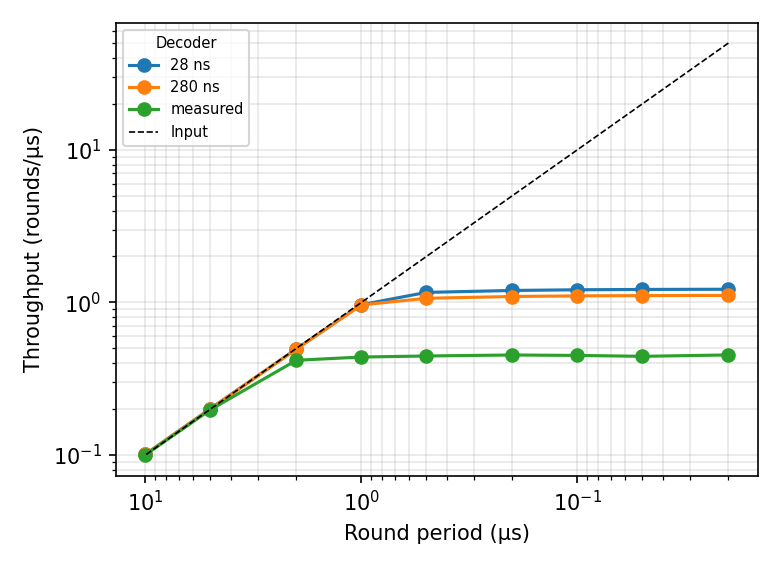

reaction.png


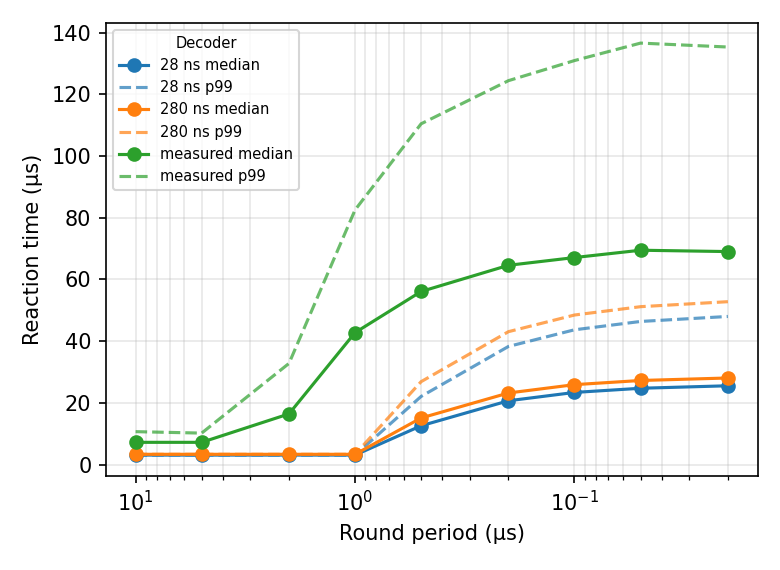

backlog.png


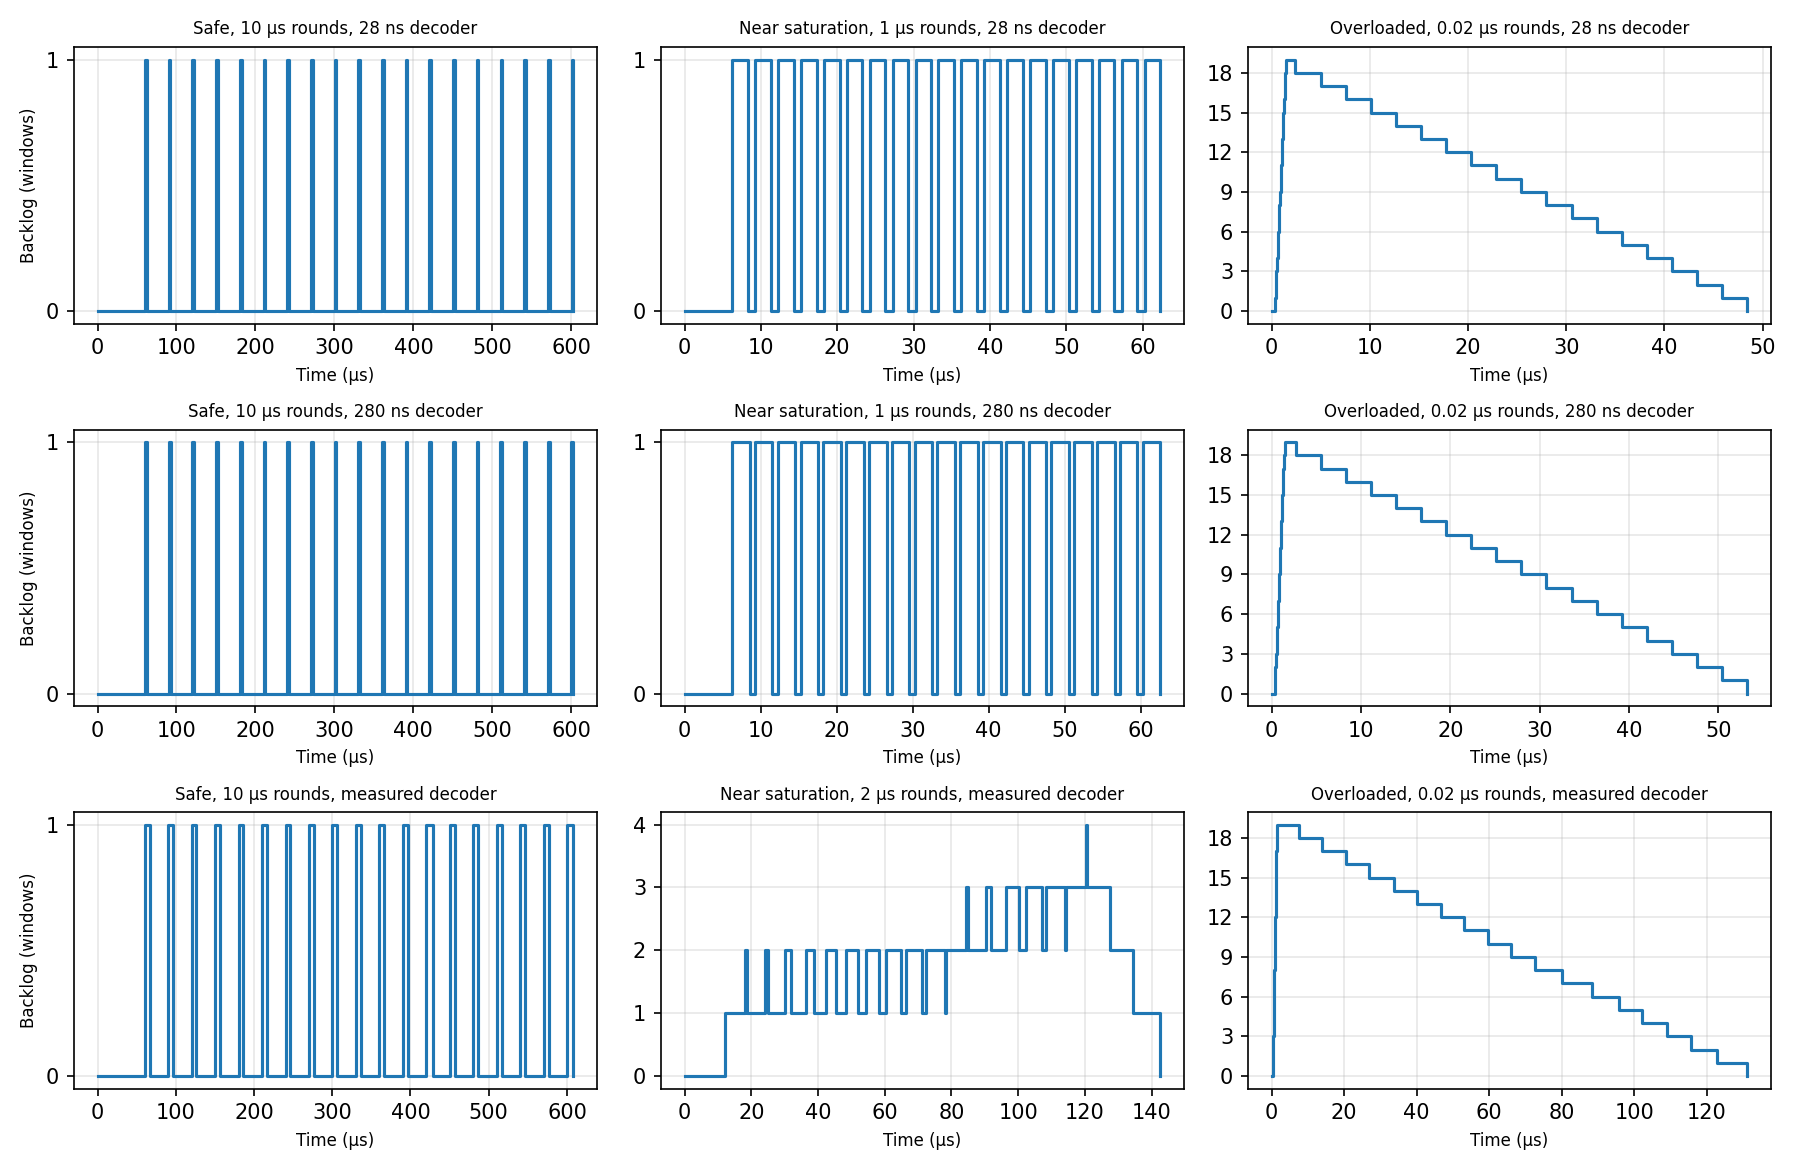

window_timeline.png


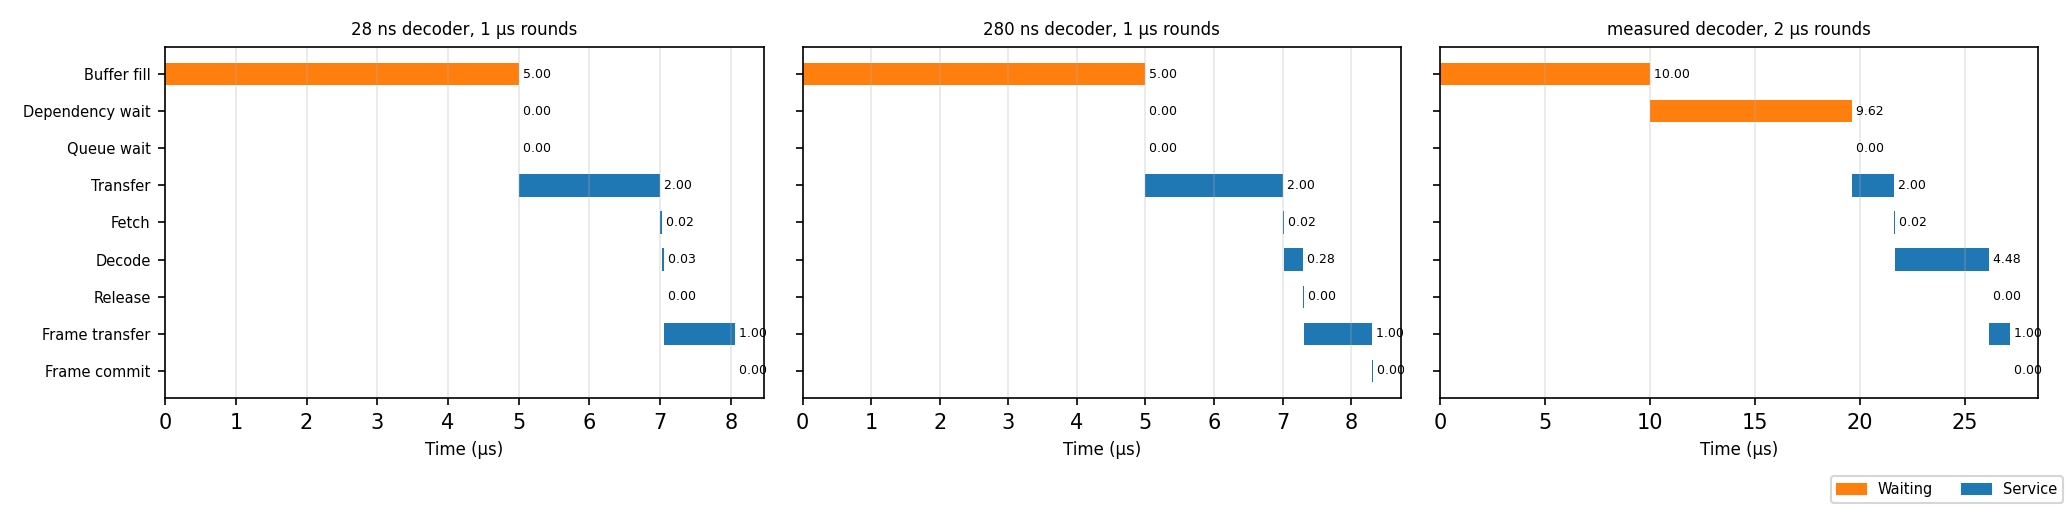

ler/ler.png


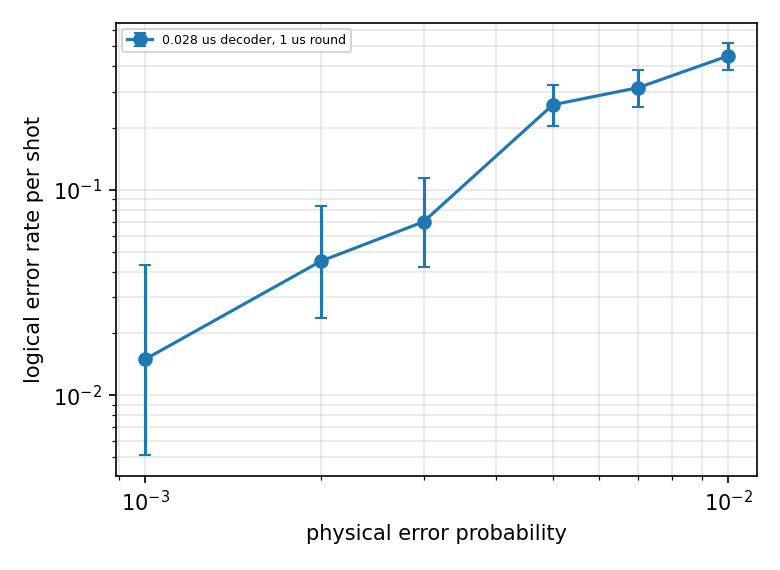

In [16]:
from IPython.display import Image, display

RESULTS = "experiments/results/baseline_closed_loop"
FIGURES = ("throughput.png", "reaction.png", "backlog.png", "window_timeline.png", "ler/ler.png")
for name in FIGURES:
    path = os.path.join(RESULTS, name)
    if os.path.exists(path):
        print(name)
        display(Image(filename=path))
    else:
        print(name, "(not in the results folder; run the sweep that produces it)")


## 16. Where correctness and timing are checked against outside references

- Windowed and unwindowed decoding through the loop vs whole-circuit PyMatching on identical shots: Gate 9, `results/validation/windowing_vs_reference.md` (identical predictions shot for shot).
- The window chain timing vs SWIPER (ASPLOS 2025), same program, run separately: Gate 8, `results/validation/loop_swiper.md`, and the two side-by-side scripts `validation/swiper_sliding_memory.py`, `validation/decsim_sliding_memory.py`.
- Links vs ns-3 and SimPy: Gate 6. Controller (packing, feedback streams, releases) vs SimPy / ns-3 / RFC 815: Gate 7. QPU cadence vs SimPy: Gate 4. Real data through a decode wait vs Stim, qLDPC, PyMatching: Gate 5. Google Willow hardware data replayed through the loop: identical to whole-shot PyMatching shot for shot (one equal-weight tie).

## 17. Module status for the target architecture

| Module | Folder | State |
|---|---|---|
| Frontend (circuit and QLX programs), planner, execution runtime | `decsim/frontends/` | built; logical circuit -> Stim for a general program is the open frontend question |
| QPU: cycle clock, Stim / recorded / timing-only devices, code geometry | `decsim/qpu/` | built, Gates 4, 5, Willow |
| Controller: pulses to binary, syndrome packing, feedback streams | `decsim/controller/` | built, Gate 7 |
| Buffer 0 | `decsim/syndrome_buffer/` | built (unbounded in the baseline; finite slots and holds exist) |
| Window manager: sliding / parallel / sandwich / no windowing, boundaries, ledger | `decsim/windows/` | built, Gates 1, 2, 8, 9 |
| Decoder manager: weak scheduler, units, per-unit decoder memory, engine (fetch / algorithm / release at a clock) | `decsim/decoders/` | built; PyMatching, Fusion Blossom checked (Gate 3); the ASIC card is one latency number, no internal pipeline model yet |
| Links (ten cards, serialization and queueing) | `decsim/links/` | built, Gate 6 |
| Pauli frame, conditional release | `decsim/pauli_frame/` | built (minimal frame) |
| Strong tier, weak/strong switching, escalation | `decsim/decoders/` | built, off in the baseline |
| Confidence estimator, G threshold | `decsim/confidence/` | placeholder; rule not decided |
| Reorder buffer | none | not built; not in the baseline by decision |

## 18. Open questions, as agreed

- Confidence estimate and threshold: start offline with the decoder-switching paper's rule, show with numbers whether a fixed threshold is good enough before anything adaptive; hardware (inside the ASIC or a separate comparator) only after the rule is fixed.
- The weak decoder's internal pipeline: today fetch cycles + algorithm + release cycles at a clock; a fetch / decode / execute / write-back model can replace the algorithm number later without changing the rest.
- Controller outward path: the sources (Khalid, XQsim, Google, PECOS, SWIPER, QLX) put the program above the controller and charge no binary-to-pulse cost; XQsim alone has a depth-2 stall-coupled instruction buffer. decsim matches the majority; an instruction buffer can be added as a contained change if wanted.
- Frontend: how a logical circuit becomes a Stim circuit for a general program (QLX lowers to analytical estimates only); for Margaret.
